# Qwen2.5-1.5B DeepReasoning ablation

This executed notebook is the presentation artifact. It shows the training/evaluation code path, but loads saved cloud artifacts so the notebook is fast and reproducible during class.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Markdown, Image, display

ART = Path('artifacts_qwen15b')
df = pd.read_csv(ART / 'qwen15b_screen_summary.csv')
confirm = json.loads((ART / 'confirm_qwen15_len1024_r8_a16_lr5e5_e3_es_greedy100' / 'evaluation_summary.json').read_text())
report_md = (ART / 'QWEN15B_PRESENTATION_REPORT.md').read_text()

def pct(x):
    return f'{100*x:.1f}%'

print('Loaded artifacts from', ART)
print('Screened runs:', len(df))
print('Confirmation examples:', confirm['n_examples'])

Loaded artifacts from artifacts_qwen15b
Screened runs: 3
Confirmation examples: 100


## 1. Research question and conclusion

We switched from Qwen2.5-3B to Qwen2.5-1.5B because the 3B model was strong enough that the dataset was less revealing. The adapter learns the required reasoning format, but does not improve loose final-answer accuracy over the base model.

In [2]:
display(Markdown(report_md))

# Qwen2.5-1.5B DeepReasoning ablation report

## One-slide conclusion

We repeated the QLoRA DeepReasoning pipeline with `Qwen/Qwen2.5-1.5B-Instruct` because the 3B model was less stressed by the dataset. The best adapter was `qwen15_len1024_r8_a16_lr5e5_e3_es`.

| Metric | Base | Adapter | Interpretation |
|---|---:|---:|---|
| Strict tagged answer, 100 questions | 0.0% | 48.0% | Adapter wins because the required format matters. |
| Loose numeric answer, 100 questions | 55.0% | 49.0% | Base remains slightly better at raw math answers. |
| Valid required format | 0.0% | 75.0% | LoRA mainly teaches format/instruction following. |

## Why this pipeline

- Same fixed training split and GSM8K evaluation indices across runs.
- Separate `artifacts_qwen15b` root so no cached 3B base generations contaminate 1.5B results.
- 30-question greedy screens for quick hyperparameter comparison.
- 100-question no-retraining confirmation only for the best screened adapter.
- Strict and loose metrics are both reported because format compliance and final-answer accuracy answer different questions.

## Runtime decisions

- Batch 32 / grad accum 1 OOMed near full VRAM.
- Batch 16 / grad accum 2 also OOMed during the fp32 full-vocabulary loss.
- Batch 8 / grad accum 4 was stable and kept the same effective batch size of 32.
- All stable runs used 3 epochs with early stopping enabled. In practice, validation loss kept improving, so all three ran the full 3 epochs.

## 30-question screen

| run                                |   rank |   alpha |     lr |   epochs |   train_batch |   grad_accum |   effective_batch |   trainable_params_m |   truncation_rate |   eval_loss |   best_eval_loss |   train_minutes |   max_gpu_gib |   strict_accuracy_30 |   loose_accuracy_30 |   format_rate_30 |   reflection_rate_30 |   mean_latency_s_30 |
|:-----------------------------------|-------:|--------:|-------:|---------:|--------------:|-------------:|------------------:|---------------------:|------------------:|------------:|-----------------:|----------------:|--------------:|---------------------:|--------------------:|-----------------:|---------------------:|--------------------:|
| qwen15_len1024_r8_a16_lr5e5_e3_es  |      8 |      16 | 0.0001 |   3.0000 |             8 |            4 |                32 |               9.2324 |            0.1500 |      0.4018 |           0.4018 |          9.2226 |       56.2719 |               0.6333 |              0.6333 |           0.9000 |               0.9000 |             15.3797 |
| qwen15_len1024_r8_a16_lr2e5_e3_es  |      8 |      16 | 0.0000 |   3.0000 |             8 |            4 |                32 |               9.2324 |            0.1500 |      0.4558 |           0.4558 |          9.2346 |       56.2719 |               0.5667 |              0.6333 |           0.8000 |               0.8000 |             17.3790 |
| qwen15_len1024_r16_a32_lr5e5_e3_es |     16 |      32 | 0.0001 |   3.0000 |             8 |            4 |                32 |              18.4648 |            0.1500 |      0.3832 |           0.3832 |          9.2382 |       56.3761 |               0.5333 |              0.5667 |           0.8000 |               0.8333 |             16.4729 |

The screen selected `qwen15_len1024_r8_a16_lr5e5_e3_es` because it had the best strict accuracy (63.3%) and best format rate (90.0%). The r=16 run had lower validation loss but worse answer accuracy, which is why we did not rely on validation loss alone.

## Final interpretation

The best defensible configuration is `qwen15_len1024_r8_a16_lr5e5_e3_es` if the assignment rewards structured reasoning traces. If the only objective is raw GSM8K numeric accuracy, the base 1.5B model is still slightly better. The experiment therefore demonstrates a format-following gain with a raw-answer tradeoff.


## 2. Training configuration we actually used

The next cells show the training setup. `RUN_FULL_TRAINING` is deliberately `False`: the heavy training already ran on the RTX PRO 6000 and the notebook loads those saved artifacts.

In [3]:
# This cell documents the actual training configuration.
# It is not executed during presentation; the executed results are loaded from artifacts.
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'
    DATA_PATH = 'data/sft_reasoning_2k.jsonl'
    ARTIFACT_ROOT = 'artifacts_qwen15b'

    MAX_LEN = 1024
    LORA_R = 8
    LORA_ALPHA = 16
    LEARNING_RATE = 5e-5
    NUM_EPOCHS = 3

    TRAIN_BATCH_SIZE = 8
    GRADIENT_ACCUMULATION_STEPS = 4
    EFFECTIVE_BATCH_SIZE = TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
    EVAL_BATCH_SIZE = 8
    GRADIENT_CHECKPOINTING = False

    EVAL_PROBLEMS = 30
    MAX_NEW_TOKENS = 768
    RUN_SELF_CONSISTENCY = False

## 3. Core QLoRA training code

This is the implementation: 4-bit NF4 loading, LoRA target modules, Trainer settings, early stopping, and adapter saving.

In [4]:
# Core QLoRA training cell used by the experiment.
# Kept behind RUN_FULL_TRAINING so this presentation notebook opens quickly.
if RUN_FULL_TRAINING:
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    from transformers import DataCollatorForSeq2Seq, EarlyStoppingCallback, Trainer, TrainingArguments
    import torch

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    quantization = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=quantization,
        device_map={'': 0},
        torch_dtype=torch.bfloat16,
    )
    model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=0.05,
        bias='none',
        task_type='CAUSAL_LM',
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                        'gate_proj', 'up_proj', 'down_proj'],
    )
    model = get_peft_model(model, lora_config)

    args = TrainingArguments(
        output_dir=f'{ARTIFACT_ROOT}/{RUN_NAME}/checkpoints',
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=NUM_EPOCHS,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type='cosine',
        warmup_ratio=0.03,
        optim='paged_adamw_8bit',
        bf16=True,
        tf32=True,
        gradient_checkpointing=GRADIENT_CHECKPOINTING,
        logging_steps=1,
        eval_strategy='steps',
        eval_steps=20,
        save_strategy='steps',
        save_steps=20,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        report_to=[],
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tokenized,
        eval_dataset=eval_tokenized,
        data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True,
                                             label_pad_token_id=-100,
                                             pad_to_multiple_of=8),
        processing_class=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3,
                                         early_stopping_threshold=5e-4)],
    )
    trainer.train()
    trainer.evaluate()
    trainer.save_model(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

## 4. Evaluation code and why there are two metrics

Strict accuracy asks whether the model obeyed the required format. Loose accuracy asks whether the final numeric answer can be recovered anywhere in the trace.

In [5]:
# Evaluation logic used for both the 30-question screen and 100-question confirmation.
# Strict accuracy requires the model to place the final answer inside <answer> tags.
# Loose accuracy extracts the last number from the whole trace, even if tags are missing.
import re

SYSTEM_INSTRUCTION = """You are a meticulous reasoning tutor.
For every problem, answer using EXACTLY these tags in order:
<thinking>
Reason step by step. Show every intermediate calculation.
</thinking>
<reflection>
Re-check your reasoning. Look for arithmetic slips or wrong assumptions.
</reflection>
<answer>
Give only the final answer.
</answer>"""

def extract_tag(text: str, tag: str) -> str:
    match = re.search(fr'<{tag}>(.*?)</{tag}>', text, re.DOTALL | re.IGNORECASE)
    return match.group(1).strip() if match else ''

def normalize_number(text: str) -> str:
    numbers = re.findall(r'-?\d+(?:\.\d+)?', str(text).replace(',', '').replace('$', ''))
    if not numbers:
        return ''
    value = float(numbers[-1])
    return str(int(value)) if value.is_integer() else str(value)

def score_trace(trace: str, gold: str) -> dict:
    thinking = extract_tag(trace, 'thinking')
    reflection = extract_tag(trace, 'reflection')
    answer = extract_tag(trace, 'answer')
    strict_prediction = normalize_number(answer)
    loose_prediction = strict_prediction or normalize_number(trace)
    return {
        'valid_format': bool(thinking and reflection and answer),
        'has_reflection': bool(reflection),
        'strict_correct': strict_prediction == gold,
        'loose_correct': loose_prediction == gold,
    }

## 5. Hyperparameter grid and saved training artifacts

This table is loaded from artifacts, not recomputed. It is the evidence used to select the leader.

In [6]:
cols = ['run', 'rank', 'alpha', 'lr', 'train_batch', 'grad_accum', 'effective_batch', 'eval_loss', 'strict_accuracy_30', 'loose_accuracy_30', 'format_rate_30', 'train_minutes', 'max_gpu_gib']
display(df[cols])

,run,rank,alpha,lr,train_batch,grad_accum,effective_batch,eval_loss,strict_accuracy_30,loose_accuracy_30,format_rate_30,train_minutes,max_gpu_gib
0,qwen15_len1024_r8_a16_lr5e5_e3_es,8,16,0.00005,8,4,32,0.401758,0.633333,0.633333,0.9,9.222645,56.271918
1,qwen15_len1024_r8_a16_lr2e5_e3_es,8,16,0.00002,8,4,32,0.455819,0.566667,0.633333,0.8,9.234625,56.271918
2,qwen15_len1024_r16_a32_lr5e5_e3_es,16,32,0.00005,8,4,32,0.383190,0.533333,0.566667,0.8,9.238208,56.376098


## 6. Charts: screen accuracy and loss/accuracy relationship

The r=16 adapter had the best validation loss but worse strict accuracy. That is why the final choice uses held-out generation behavior, not validation loss alone.

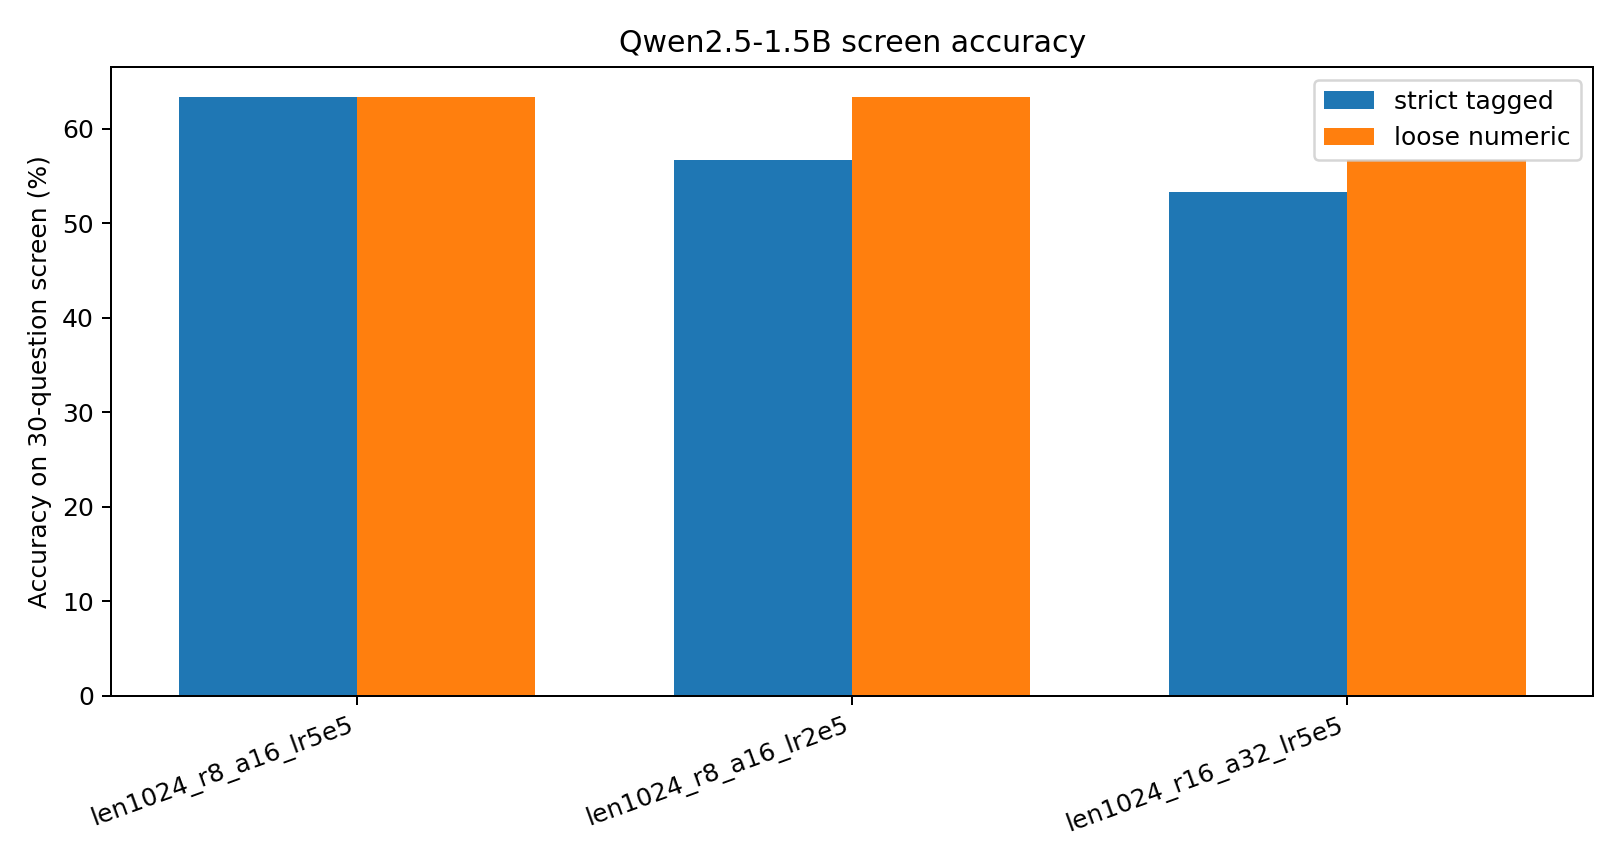

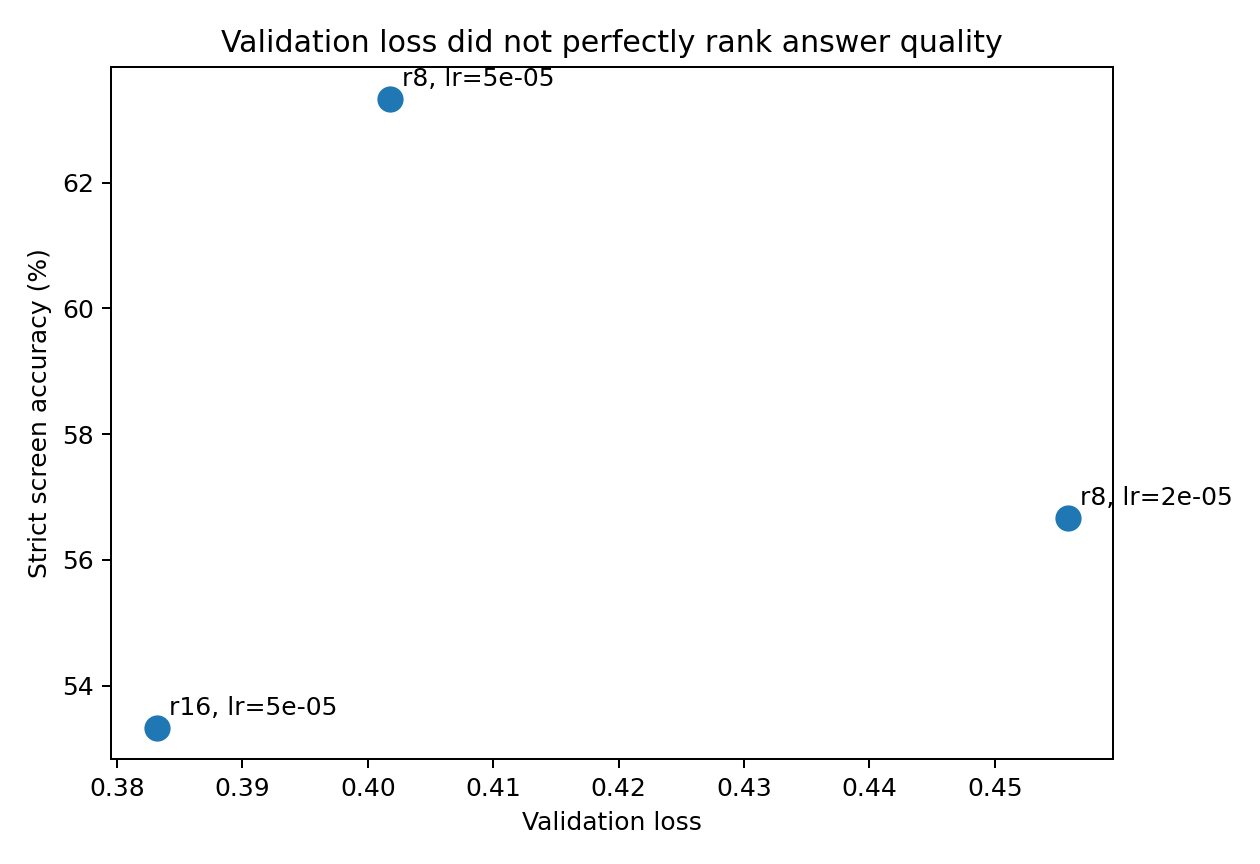

In [7]:
display(Image(filename=str(ART / 'presentation_plots' / 'screen_accuracy.png')))
display(Image(filename=str(ART / 'presentation_plots' / 'loss_vs_accuracy.png')))

## 7. Training stability and runtime choices

Batch 32 and batch 16 OOMed; batch 8 with grad accumulation 4 was stable and preserved effective batch size 32.

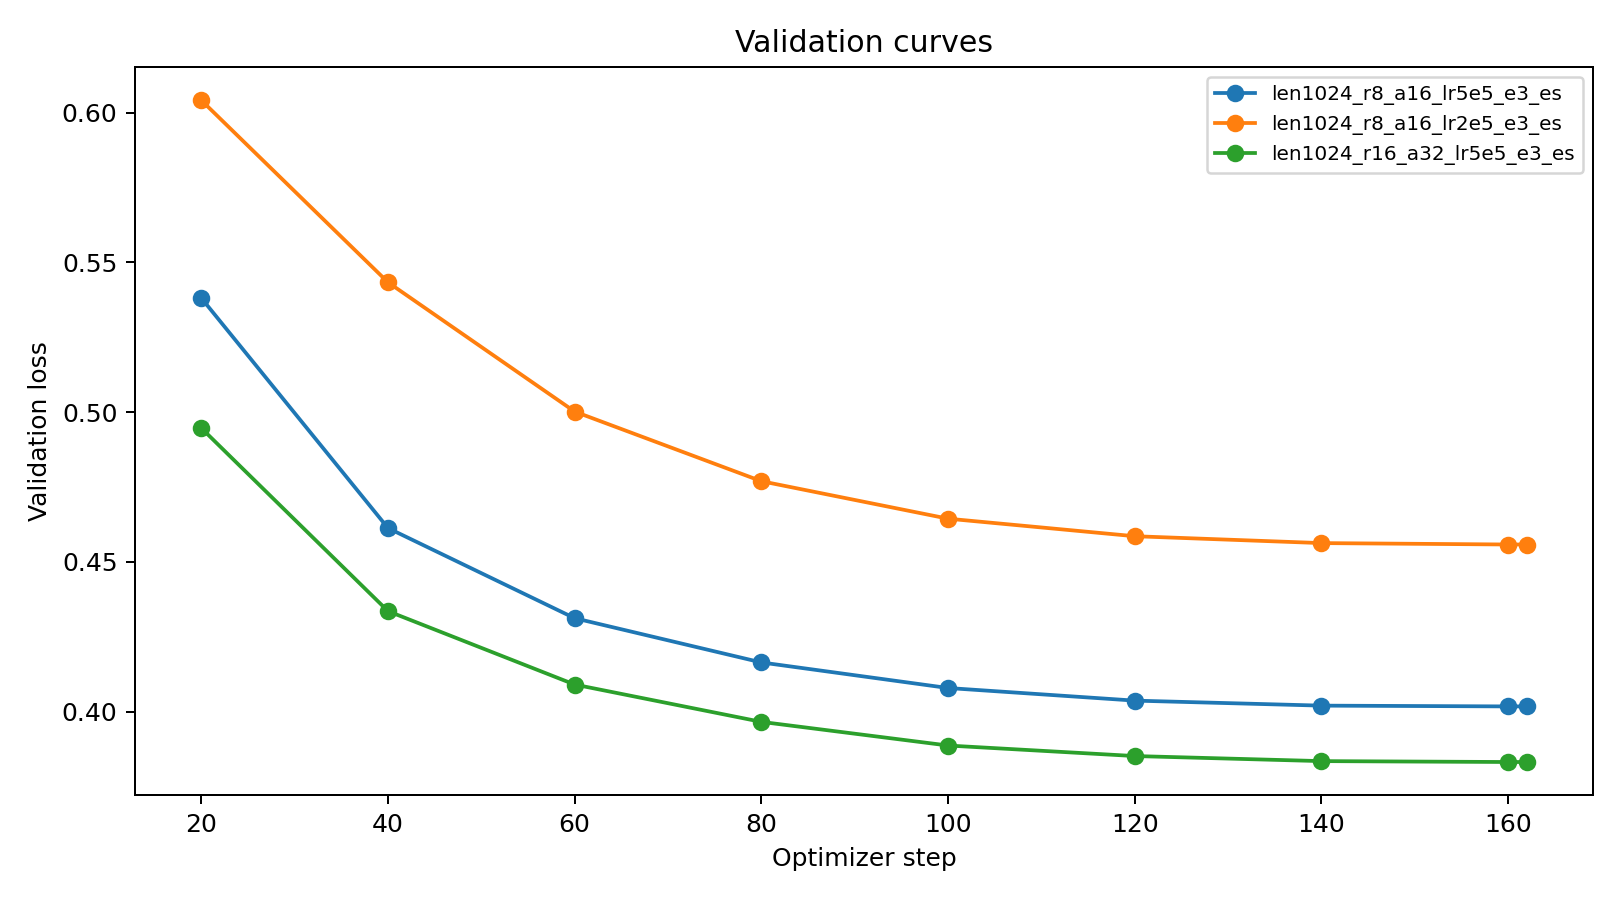

--- oom_qwen15_len1024_r8_a16_lr5e5_e3_es_bs16 ---
# OOM record

Batch 16 / grad accum 2 still OOMed during fp32 loss over full vocab logits. Relaunch uses batch 8 / grad accum 4.

2026-07-07T20:41:51.115357Z

--- oom_qwen15_len1024_r8_a16_lr5e5_e3_es_bs32 ---
# OOM / interrupted batch-32 attempt

Batch 32 / grad accum 1 was not VRAM safe. Relaunch uses batch 16 / grad accum 2.

2026-07-07T20:40:32.358790Z



In [8]:
display(Image(filename=str(ART / 'presentation_plots' / 'validation_curves.png')))
for oom_dir in sorted(ART.glob('oom_*')):
    record = oom_dir / 'OOM_RECORD.md'
    if record.exists():
        print(f'--- {oom_dir.name} ---')
        print(record.read_text())

## 8. 100-question confirmation

After the 30-question screen, only the leader was confirmed on 100 questions without retraining.

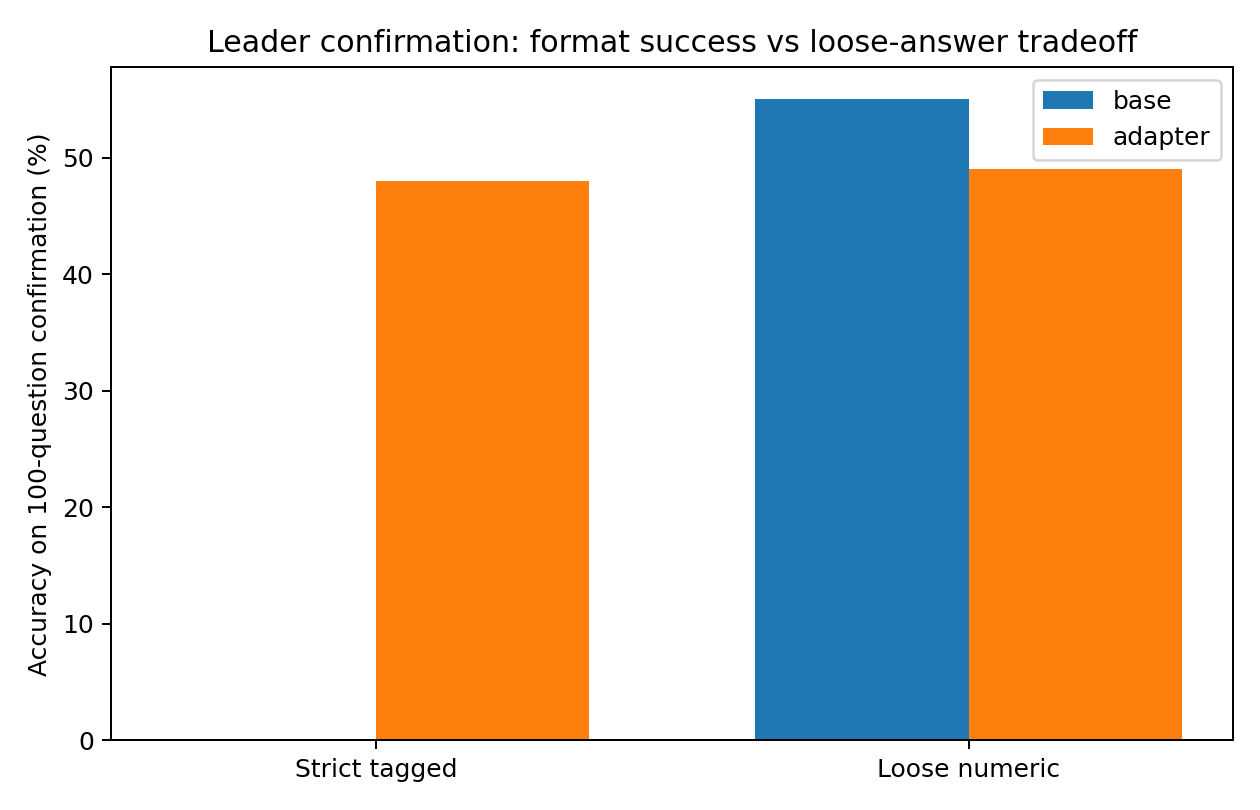

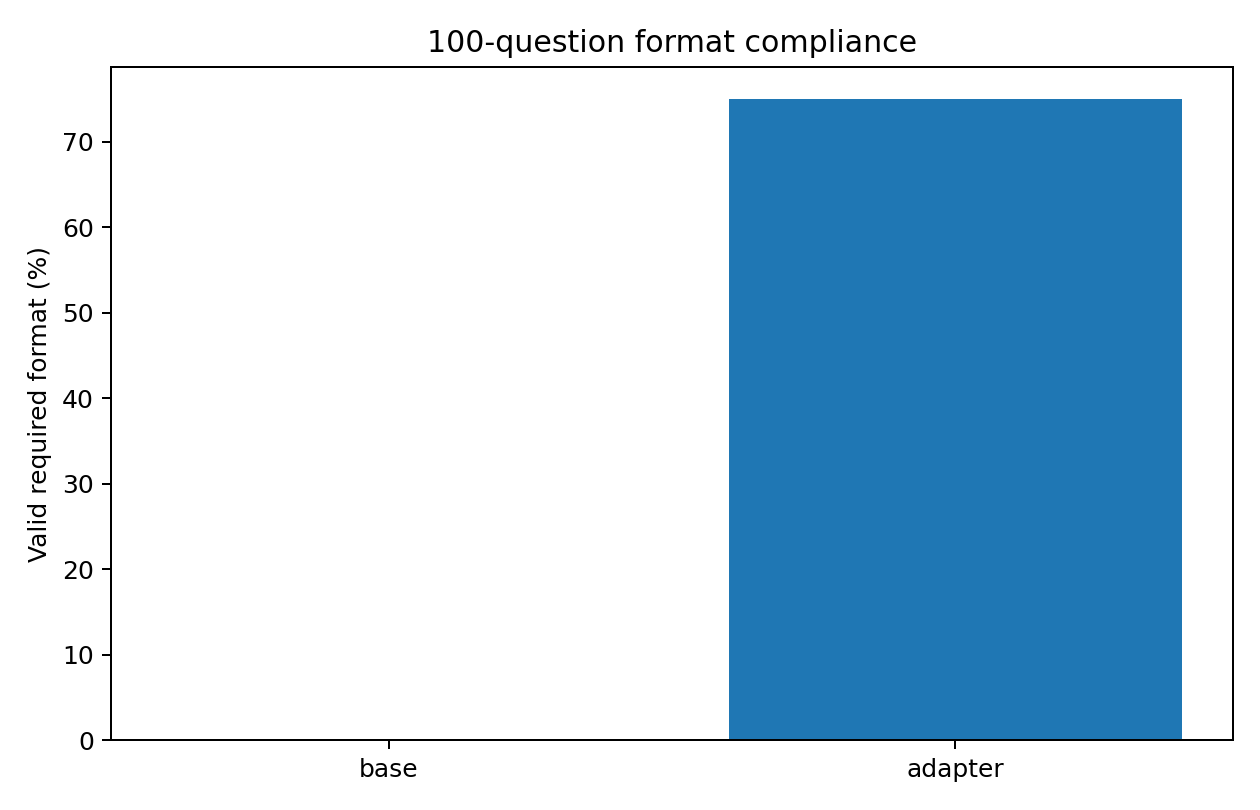

{
  "completed_at_utc": "2026-07-07T22:12:55.716995+00:00",
  "model_id": "Qwen/Qwen2.5-1.5B-Instruct",
  "adapter_dir": "/home/zeus/DeepReasoning/artifacts_qwen15b/qwen15_len1024_r8_a16_lr5e5_e3_es/adapter",
  "n_examples": 100,
  "max_new_tokens": 768,
  "strict_tag_answer": {
    "base_accuracy": 0.0,
    "adapter_accuracy": 0.48,
    "adapter_minus_base": 0.48,
    "bootstrap_95_ci": [
      0.38,
      0.58
    ],
    "adapter_wins": 48,
    "base_wins": 0,
    "ties": 52
  },
  "loose_numeric_answer": {
    "base_accuracy": 0.55,
    "adapter_accuracy": 0.49,
    "adapter_minus_base": -0.06,
    "bootstrap_95_ci": [
      -0.19,
      0.06
    ],
    "adapter_wins": 18,
    "base_wins": 24,
    "ties": 58
  },
  "base_valid_format_rate": 0.0,
  "adapter_valid_format_rate": 0.75,
  "base_reflection_rate": 0.0,
  "adapter_reflection_rate": 0.75,
  "base_mean_latency_seconds": 4.191796562671661,
  "adapter_mean_latency_seconds": 15.685780265331267
}


In [9]:
display(Image(filename=str(ART / 'presentation_plots' / 'confirm_accuracy.png')))
display(Image(filename=str(ART / 'presentation_plots' / 'confirm_format_rate.png')))
print(json.dumps(confirm, indent=2))

## 9. Final takeaway

Use `qwen15_len1024_r8_a16_lr5e5_e3_es` if structured reasoning traces are required. If the only objective is loose GSM8K numeric answer accuracy, the base 1.5B model is still slightly better. The experiment demonstrates a format-following gain with a raw-answer tradeoff.